# Classical Forecasting Methods

**Data:** NIFTY 50 (`^NSEI`), daily close 2016-08-17 → 2026-08-17, resampled to month-end. Saved locally at `../data/nifty50_daily.csv`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
daily = pd.read_csv("../data/nifty50_daily.csv", parse_dates=["ds"]).set_index("ds")
px = daily["close"]

# month-end series; drop the final partial month
nifty = px.resample("ME").last()
nifty = nifty[nifty.index < "2026-08-01"]
nifty.index.freq = "ME"

M = 12                       # seasonal period (months in a year)
H = 24                       # holdout: last 2 years
train, test = nifty[:-H], nifty[-H:]

print(f"daily   {len(px):5d} obs   {px.index.min().date()} -> {px.index.max().date()}")
print(f"monthly {len(nifty):5d} obs   {nifty.index.min().date()} -> {nifty.index.max().date()}")
print(f"train   {len(train):5d}   test {len(test)}   ({test.index.min().date()} -> {test.index.max().date()})")
print(f"train ends {train.iloc[-1]:,.0f}   test mean {test.mean():,.0f}   test ends {test.iloc[-1]:,.0f}")

daily    2465 obs   2016-08-17 -> 2026-08-17
monthly   120 obs   2016-08-31 -> 2026-07-31
train      96   test 24   (2024-08-31 -> 2026-07-31)
train ends 24,951   test mean 24,470   test ends 24,384


## 0. What the series looks like

Two facts decide which methods can work, so establish them first: **is there a unit root**, and **is there seasonality**.

ADF on price      p = 0.8807
ADF on log return p = 2.391e-25
ACF price  lags 1-5: [0.999 0.998 0.997 0.995 0.994]
ACF return lags 1-5: [-0.045  0.028  0.006  0.019  0.083]
annualised drift 10.62%   annualised vol 16.32%

STL on log(monthly): F_trend = 0.968   F_seasonal = 0.000


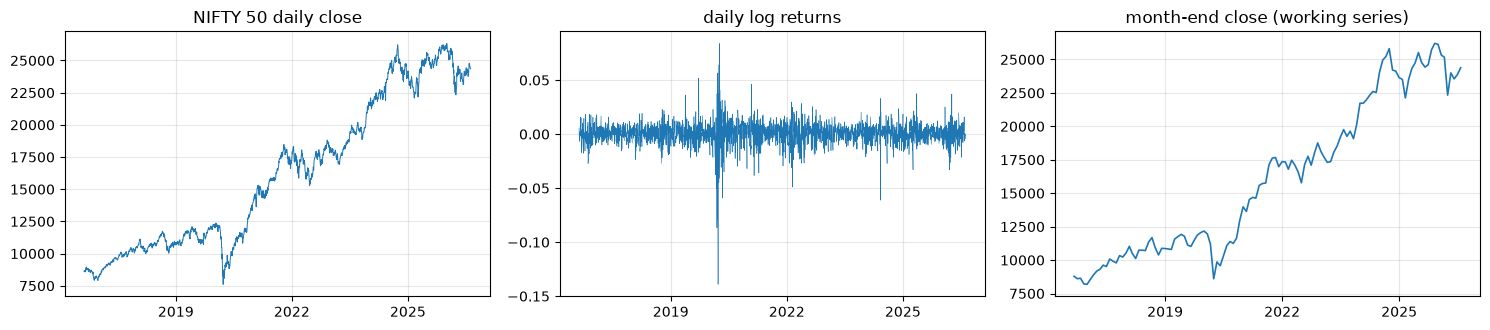

In [3]:
log_ret = np.log(px).diff().dropna()

print(f"ADF on price      p = {adfuller(px, autolag='AIC')[1]:.4g}")
print(f"ADF on log return p = {adfuller(log_ret, autolag='AIC')[1]:.4g}")
print(f"ACF price  lags 1-5: {np.round(acf(px, nlags=5)[1:6], 3)}")
print(f"ACF return lags 1-5: {np.round(acf(log_ret, nlags=5)[1:6], 3)}")
print(f"annualised drift {log_ret.mean()*252*100:5.2f}%   annualised vol {log_ret.std()*np.sqrt(252)*100:5.2f}%")

stl = STL(np.log(nifty), period=M, robust=True).fit()
r_, s_, t_ = stl.resid, stl.seasonal, stl.trend
F_seas  = max(0, 1 - r_.var() / (r_ + s_).var())
F_trend = max(0, 1 - r_.var() / (r_ + t_).var())
print(f"\nSTL on log(monthly): F_trend = {F_trend:.3f}   F_seasonal = {F_seas:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 3.4))
axes[0].plot(px.index, px.values, lw=0.7);        axes[0].set_title("NIFTY 50 daily close")
axes[1].plot(log_ret.index, log_ret.values, lw=0.4); axes[1].set_title("daily log returns")
axes[2].plot(nifty.index, nifty.values, lw=1.2);  axes[2].set_title("month-end close (working series)")
for a in axes:
    a.xaxis.set_major_locator(mdates.YearLocator(3))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout(); plt.show()

- **Price has a unit root** (ADF p = 0.88; ACF 0.999, 0.998, 0.997 — decaying linearly). **Log returns are white noise** (ADF p ≈ 2e-25; ACF −0.045, 0.028, 0.006). The price is a **random walk with drift**: +10.6% a year with 16.3% volatility.
- **F_trend = 0.968, F_seasonal = 0.000.** Very strong trend, literally no stable month-of-year effect.

→ Expect the trend-based methods to matter and the seasonal ones to have nothing to fit. Both expectations are tested below rather than assumed.

## 1. Naïve forecasting

**Naïve method** — the forecast is the last observed value, flat for every horizon:

$$\hat{y}_{T+h|T} = y_T$$

**Seasonal naïve** — the value from the same point in the previous season:

$$\hat{y}_{T+h|T} = y_{T+h-m\lceil h/m \rceil}$$

**Why it is the baseline that matters.** For a random walk, $\mathbb{E}[y_{T+h} \mid y_T] = y_T$ — the naïve forecast is not a lazy placeholder, it is the **optimal** forecast. Since asset prices are close to random walks, any model that cannot beat naïve on price data has demonstrated nothing. It also costs nothing to compute, needs no parameters, and defines the denominator of MASE (a MASE above 1 means you lost to it).

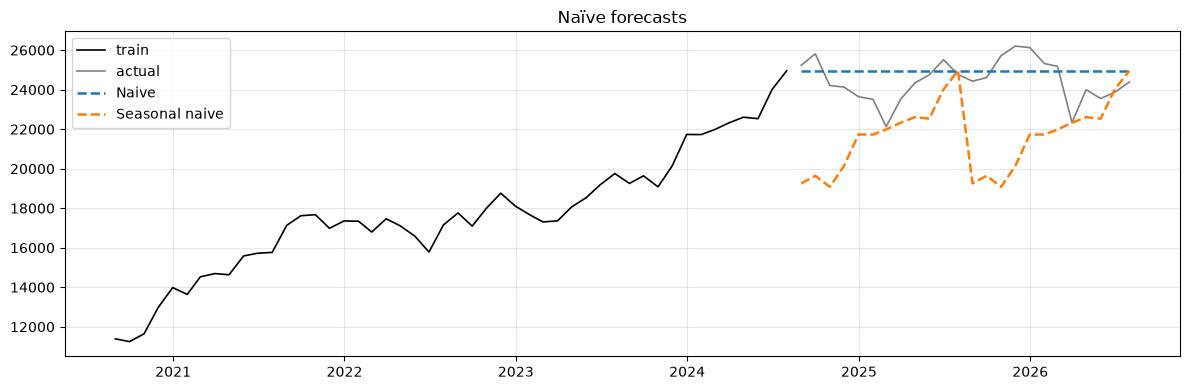

In [4]:
def naive(tr, h):
    return np.repeat(tr.iloc[-1], h)

def seasonal_naive(tr, h, m=M):
    last = tr.iloc[-m:].values
    return last[[i % m for i in range(h)]]

fc = {}
fc["Naive"]          = naive(train, H)
fc["Seasonal naive"] = seasonal_naive(train, H)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index[-48:], train.values[-48:], lw=1.2, color="black", label="train")
ax.plot(test.index, test.values, lw=1.2, color="grey", label="actual")
for k in ("Naive", "Seasonal naive"):
    ax.plot(test.index, fc[k], lw=1.8, ls="--", label=k)
ax.legend(); ax.set_title("Naïve forecasts")
plt.tight_layout(); plt.show()

## 2. Drift method

Naïve, but allowed to continue the average slope seen in the training data:

$$\hat{y}_{T+h|T} = y_T + h \cdot \frac{y_T - y_1}{T - 1}$$

The slope is just the line through the **first and last** points — nothing in between matters.

**Connection with the random walk with drift.** For $y_t = \mu + y_{t-1} + \varepsilon_t$, the optimal forecast is $\hat{y}_{T+h|T} = y_T + h\mu$, and the MLE of $\mu$ is exactly $(y_T - y_1)/(T-1)$. So the drift method **is** the optimal forecast for a random walk with drift, in the same way plain naïve is optimal for a driftless one. Given §0 showed NIFTY is a random walk with +10.6%/yr drift, drift is the theoretically motivated method here.

drift slope = 170.16 points/month  (8.18% per year)


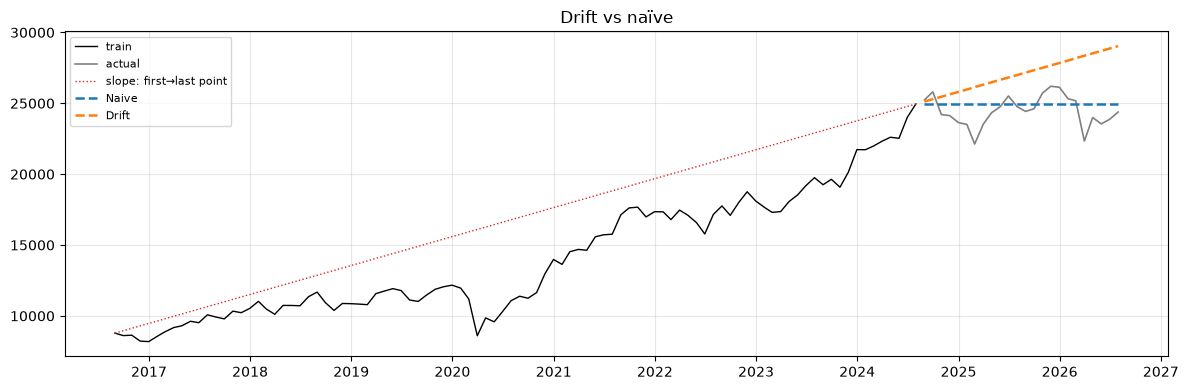

In [5]:
def drift(tr, h):
    slope = (tr.iloc[-1] - tr.iloc[0]) / (len(tr) - 1)
    return tr.iloc[-1] + np.arange(1, h + 1) * slope

fc["Drift"] = drift(train, H)
slope = (train.iloc[-1] - train.iloc[0]) / (len(train) - 1)
print(f"drift slope = {slope:,.2f} points/month  ({slope*12/train.iloc[-1]*100:.2f}% per year)")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index, train.values, lw=1, color="black", label="train")
ax.plot(test.index, test.values, lw=1.2, color="grey", label="actual")
ax.plot([train.index[0], train.index[-1]], [train.iloc[0], train.iloc[-1]],
        lw=1, ls=":", color="tab:red", label="slope: first→last point")
for k in ("Naive", "Drift"):
    ax.plot(test.index, fc[k], lw=1.8, ls="--", label=k)
ax.legend(fontsize=8); ax.set_title("Drift vs naïve")
plt.tight_layout(); plt.show()

## 3. Simple moving average (SMA)

$$\hat{y}_{T+h|T} = \frac{1}{k}\sum_{i=0}^{k-1} y_{T-i}$$

The mean of the last $k$ observations, held flat across the horizon.

**Choice of window size** — the entire trade-off lives in $k$:

| $k$ | Smoothness | Responsiveness | Noise in the estimate |
|---|---|---|---|
| small | low | high — follows turns quickly | high ($\sigma/\sqrt{k}$) |
| large | high | low — lags behind turns | low |

A moving average lags a trending series by roughly $(k-1)/2$ periods, so on trending data a larger window is *systematically* biased low (rising) or high (falling).

**Limitations as a forecaster:**

- The forecast is **flat** — it cannot project a trend, so it is wrong by construction on trending data.
- **Equal weights**: the observation from $k$ periods ago counts as much as yesterday's.
- **Hard cutoff**: everything older than $k$ counts zero. A point matters fully, then not at all.
- Needs $k$ observations before it produces anything.

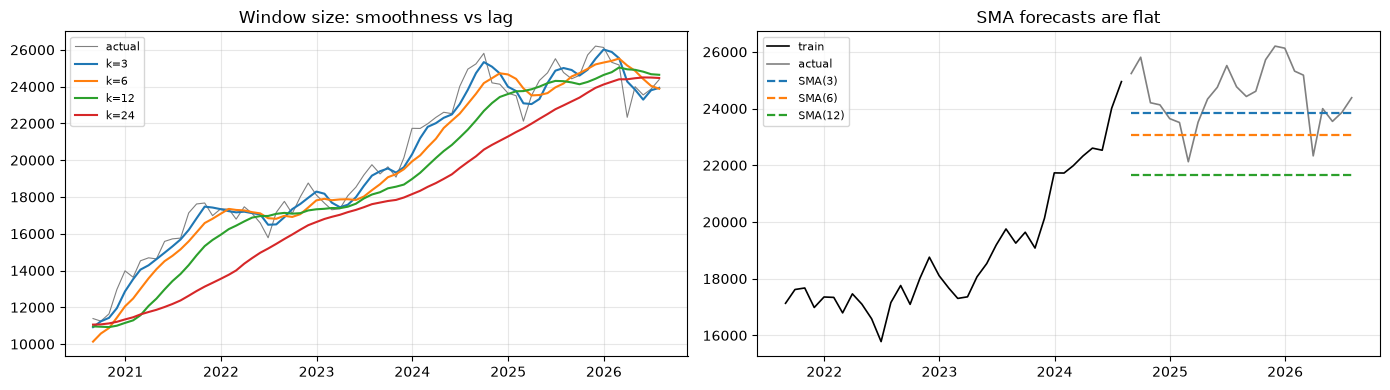

lag behind a trend ≈ (k-1)/2 periods: {3: 1.0, 6: 2.5, 12: 5.5, 24: 11.5}


In [6]:
def sma(tr, h, k):
    return np.repeat(tr.iloc[-k:].mean(), h)

for k in (3, 6, 12):
    fc[f"SMA({k})"] = sma(train, H, k)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(nifty.index[-72:], nifty.values[-72:], lw=0.8, color="grey", label="actual")
for k in (3, 6, 12, 24):
    axes[0].plot(nifty.index[-72:], nifty.rolling(k).mean().values[-72:], lw=1.5, label=f"k={k}")
axes[0].legend(fontsize=8); axes[0].set_title("Window size: smoothness vs lag")

axes[1].plot(train.index[-36:], train.values[-36:], lw=1.2, color="black", label="train")
axes[1].plot(test.index, test.values, lw=1.2, color="grey", label="actual")
for k in (3, 6, 12):
    axes[1].plot(test.index, fc[f"SMA({k})"], lw=1.6, ls="--", label=f"SMA({k})")
axes[1].legend(fontsize=8); axes[1].set_title("SMA forecasts are flat")
plt.tight_layout(); plt.show()

print("lag behind a trend ≈ (k-1)/2 periods:",
      {k: (k - 1) / 2 for k in (3, 6, 12, 24)})

## 4. Weighted moving average (WMA)

Same window, unequal weights:

$$\hat{y}_{T+h|T} = \sum_{i=0}^{k-1} w_i\, y_{T-i}, \qquad \sum_i w_i = 1,\ w_i \ge 0$$

**Choosing weights.** Linear weights $w_i \propto (k - i)$ are the common default; any decreasing scheme works. The weights must sum to 1 or the forecast is biased in level.

**Why recent observations get more weight.** In a series whose level moves, the most recent observation is the best single estimate of *where the level is now*. Older points describe a level that no longer exists, so weighting them equally drags the forecast toward the past.

**SMA vs WMA:**

| | SMA | WMA |
|---|---|---|
| Weights | equal, $1/k$ | decreasing |
| Lag on a trend | $(k-1)/2$ | smaller |
| Cutoff | abrupt at $k$ | abrupt at $k$ |
| Parameters | $k$ | $k$ + the weight scheme |

WMA reduces the lag but keeps SMA's real weakness: a hard cutoff at $k$, and a flat forecast. SES (next) fixes the cutoff.

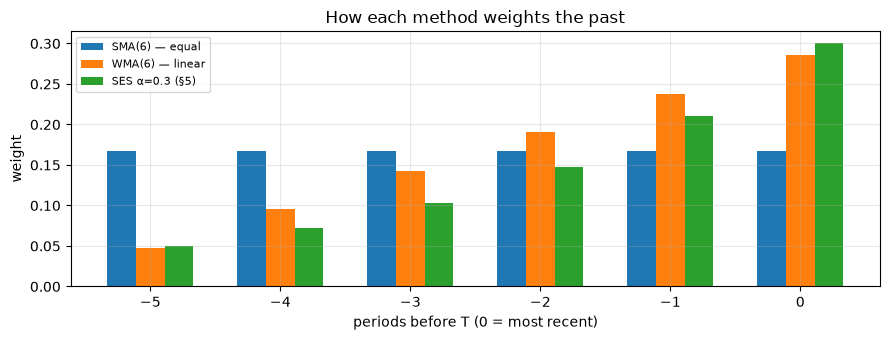

SMA(6) weights: [0.167 0.167 0.167 0.167 0.167 0.167]
WMA(6) weights: [0.048 0.095 0.143 0.19  0.238 0.286]


In [7]:
def wma(tr, h, k=6, weights=None):
    w = np.arange(1, k + 1) if weights is None else np.asarray(weights, float)
    w = w / w.sum()
    return np.repeat(np.dot(tr.iloc[-k:].values, w), h)

fc["WMA(6)"] = wma(train, H, 6)

k = 6
w_sma = np.repeat(1 / k, k)
w_wma = np.arange(1, k + 1) / np.arange(1, k + 1).sum()
w_ses = [(0.3) * (1 - 0.3) ** i for i in range(k)][::-1]     # for comparison in §5

fig, ax = plt.subplots(figsize=(9, 3.5))
idx = np.arange(-k + 1, 1)
ax.bar(idx - 0.22, w_sma, width=0.22, label="SMA(6) — equal")
ax.bar(idx,        w_wma, width=0.22, label="WMA(6) — linear")
ax.bar(idx + 0.22, w_ses, width=0.22, label="SES α=0.3 (§5)")
ax.set_xlabel("periods before T (0 = most recent)"); ax.set_ylabel("weight")
ax.legend(fontsize=8); ax.set_title("How each method weights the past")
plt.tight_layout(); plt.show()

print("SMA(6) weights:", np.round(w_sma, 3))
print("WMA(6) weights:", np.round(w_wma, 3))

## 5. Simple exponential smoothing (SES)

Every past observation contributes, with weight decaying geometrically — no cutoff.

**Level (smoothing) equation:**

$$\ell_t = \alpha y_t + (1-\alpha)\ell_{t-1}, \qquad 0 \le \alpha \le 1$$

**Forecast equation** — flat, like SMA:

$$\hat{y}_{T+h|T} = \ell_T$$

**Intuition behind exponential weighting.** Expand the recursion:

$$\ell_T = \alpha y_T + \alpha(1-\alpha) y_{T-1} + \alpha(1-\alpha)^2 y_{T-2} + \cdots$$

Weights $\alpha(1-\alpha)^i$ decay geometrically and sum to 1. Nothing is discarded; old data simply fades. Equivalently, in error-correction form $\ell_t = \ell_{t-1} + \alpha(y_t - \ell_{t-1})$ — move the level a fraction $\alpha$ of the way toward the latest surprise.

**Effect of α:**

| α | Behaviour | Suits |
|---|---|---|
| → 0 | forecast ≈ the long-run mean; very smooth, very slow | stable level, heavy noise |
| ≈ 0.3 | balanced | most series |
| → 1 | $\ell_T \to y_T$, i.e. **exactly the naïve method** | a random walk |

The effective memory is about $1/\alpha$ periods, so SES with $\alpha$ is roughly SMA with $k \approx (2-\alpha)/\alpha$.

**SES vs moving average:** SES weights decay smoothly instead of cutting off, uses all history, needs one parameter that can be estimated by MLE, and updates in $O(1)$. Both produce flat forecasts.

**When SES is appropriate:** no trend, no seasonality, a level that drifts slowly. If a trend is present the forecast will lag it permanently — that is what Holt fixes.

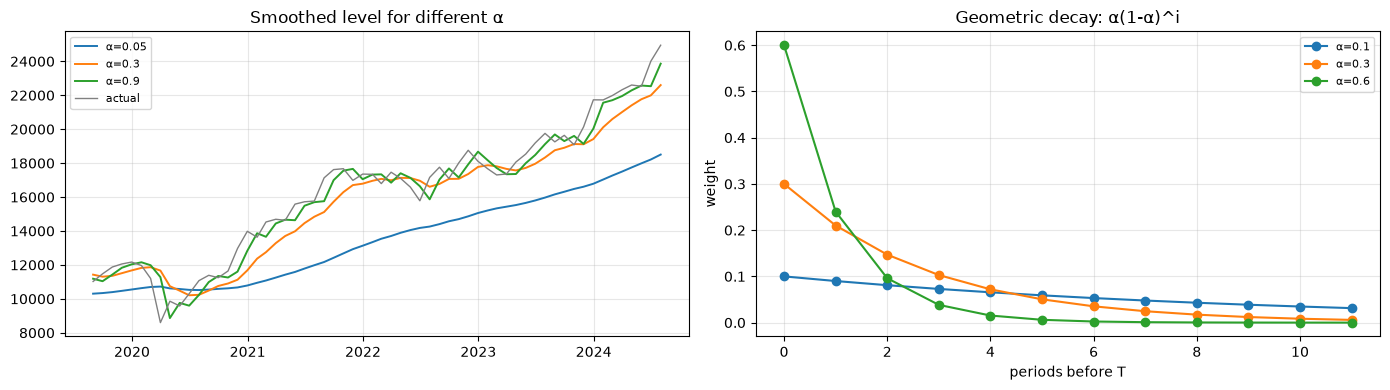

MLE-optimal α = 1.0000
SES forecast   = 24,951.15
Naive forecast = 24,951.15
identical: True


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for a in (0.05, 0.3, 0.9):
    axes[0].plot(train.index[-60:],
                 SimpleExpSmoothing(train, initialization_method="estimated")
                 .fit(smoothing_level=a, optimized=False).fittedvalues[-60:],
                 lw=1.4, label=f"α={a}")
axes[0].plot(train.index[-60:], train.values[-60:], lw=1, color="grey", label="actual")
axes[0].legend(fontsize=8); axes[0].set_title("Smoothed level for different α")

for a in (0.1, 0.3, 0.6):
    axes[1].plot(range(12), [a * (1 - a) ** i for i in range(12)], marker="o", label=f"α={a}")
axes[1].set_xlabel("periods before T"); axes[1].set_ylabel("weight")
axes[1].legend(fontsize=8); axes[1].set_title("Geometric decay: α(1-α)^i")
plt.tight_layout(); plt.show()

ses = SimpleExpSmoothing(train, initialization_method="estimated").fit()
alpha_opt = ses.params["smoothing_level"]
fc["SES"] = ses.forecast(H)

print(f"MLE-optimal α = {alpha_opt:.4f}")
print(f"SES forecast   = {fc['SES'].iloc[0]:,.2f}")
print(f"Naive forecast = {fc['Naive'][0]:,.2f}")
print(f"identical: {np.allclose(fc['SES'].values, fc['Naive'])}")

**α is estimated at exactly 1.0000, so SES collapses onto the naïve method** — the two forecast columns are bitwise identical. This is not a quirk of the optimiser: for a random walk, $\alpha = 1$ *is* the optimal choice, because the last observation already contains everything knowable about the level. Section 0 said the price is a random walk; SES independently rediscovers it.

## 6. Holt's linear trend method

**Why SES fails when a trend exists.** SES has one component — a level — and a flat forecast function. Against a rising series the level is a weighted average of *past* values, so it sits below the current one and the forecast is biased low at every horizon, with the error growing in $h$. No value of $\alpha$ fixes this; the functional form is wrong.

Holt adds a second component, the **trend** $b_t$:

$$\begin{aligned}
\text{Level:} \quad & \ell_t = \alpha y_t + (1-\alpha)(\ell_{t-1} + b_{t-1}) \\
\text{Trend:} \quad & b_t = \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*) b_{t-1} \\
\text{Forecast:} \quad & \hat{y}_{T+h|T} = \ell_T + h\, b_T
\end{aligned}$$

$\alpha$ smooths the level, $\beta^*$ smooths the trend. The forecast is a straight line — **additive (linear) trend**.

**Damped trend.** A straight line extrapolated 24 months is a strong claim. Damping shrinks it with a factor $0 < \phi < 1$:

$$\hat{y}_{T+h|T} = \ell_T + (\phi + \phi^2 + \cdots + \phi^h)\, b_T$$

As $h \to \infty$ the forecast flattens to $\ell_T + \phi b_T/(1-\phi)$ rather than diverging. Empirically damped trend is one of the most reliable general-purpose methods.

**Holt vs SES:** $\beta^* = 0$ with a zero initial trend reduces Holt to SES. Holt costs one extra parameter and buys a sloped forecast.

Holt        α=1.0000  β*=0.0000
Holt damped α=1.0000  β*=0.0000  φ=0.9950

Holt final level 24,951.2   final trend 170.16
drift slope                              170.16   <- identical
Holt vs Drift forecasts identical: True


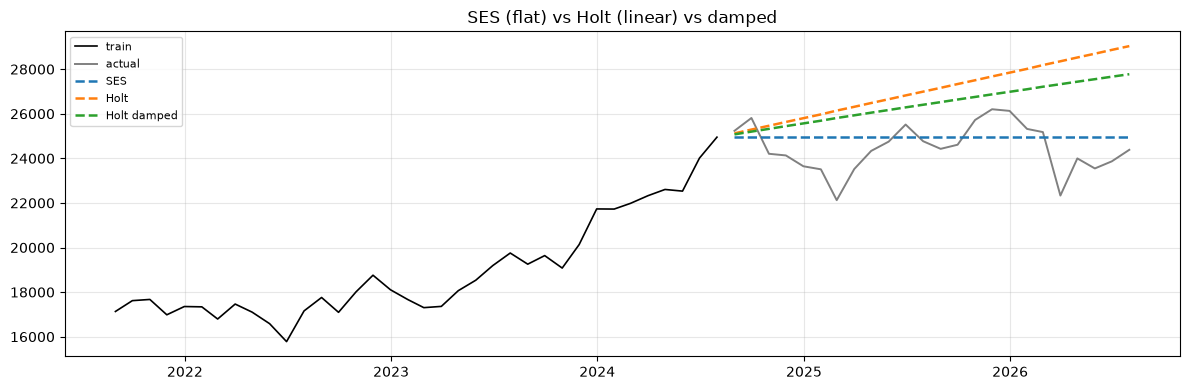

In [9]:
holt      = Holt(train, initialization_method="estimated").fit()
holt_damp = Holt(train, damped_trend=True, initialization_method="estimated").fit()

fc["Holt"]        = holt.forecast(H)
fc["Holt damped"] = holt_damp.forecast(H)

print(f"Holt        α={holt.params['smoothing_level']:.4f}  β*={holt.params['smoothing_trend']:.4f}")
print(f"Holt damped α={holt_damp.params['smoothing_level']:.4f}  "
      f"β*={holt_damp.params['smoothing_trend']:.4f}  φ={holt_damp.params['damping_trend']:.4f}")
print(f"\nHolt final level {holt.level[-1]:,.1f}   final trend {holt.trend[-1]:,.2f}")
print(f"drift slope                              {slope:,.2f}   <- identical")
print(f"Holt vs Drift forecasts identical: {np.allclose(fc['Holt'].values, fc['Drift'])}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train.index[-36:], train.values[-36:], lw=1.2, color="black", label="train")
ax.plot(test.index, test.values, lw=1.4, color="grey", label="actual")
for k in ("SES", "Holt", "Holt damped"):
    ax.plot(test.index, fc[k], lw=1.8, ls="--", label=k)
ax.legend(fontsize=8); ax.set_title("SES (flat) vs Holt (linear) vs damped")
plt.tight_layout(); plt.show()

**Holt estimates β\* = 0.0000, and its final trend (170.16/month) equals the drift slope exactly** — so Holt and Drift produce identical forecasts here. With $\beta^*=0$ the trend never updates from its fitted initial value, which the optimiser sets to the average slope. The Holt↔Drift connection is usually stated as theory; on this series it is an identity you can check.

Damping is estimated at $\phi = 0.9950$ — only mildly damped over 24 months, but enough to pull the forecast meaningfully below the undamped line.

## 7. Holt-Winters (triple exponential smoothing)

A third component for **seasonality**, with period $m$ (here $m = 12$ months).

**Additive** — seasonal swing is a fixed number of points, independent of level:

$$\begin{aligned}
\ell_t &= \alpha(y_t - s_{t-m}) + (1-\alpha)(\ell_{t-1}+b_{t-1}) \\
b_t &= \beta^*(\ell_t - \ell_{t-1}) + (1-\beta^*)b_{t-1} \\
s_t &= \gamma(y_t - \ell_{t-1} - b_{t-1}) + (1-\gamma)s_{t-m} \\
\hat{y}_{T+h|T} &= \ell_T + h b_T + s_{T+h-m(\lfloor (h-1)/m \rfloor + 1)}
\end{aligned}$$

**Multiplicative** — seasonal swing is a *percentage* of level, so it grows with the series:

$$\ell_t = \alpha \frac{y_t}{s_{t-m}} + (1-\alpha)(\ell_{t-1}+b_{t-1}), \qquad
s_t = \gamma \frac{y_t}{\ell_{t-1}+b_{t-1}} + (1-\gamma)s_{t-m}, \qquad
\hat{y}_{T+h|T} = (\ell_T + h b_T)\, s_{T+h-m(\cdots)}$$

$\gamma$ smooths the seasonal indices; $\alpha, \beta^*$ are as in Holt.

**Choosing additive vs multiplicative:** plot the series and look at the seasonal amplitude. Constant in absolute terms → additive. Growing with the level → multiplicative (or take logs and use additive, since $\log$ turns a product into a sum). Multiplicative requires strictly positive data.

**Holt vs Holt-Winters:** identical except for the seasonal term. With $\gamma = 0$ and flat seasonal indices, HW reduces to Holt. Use HW only when seasonality is real — each extra component is $m$ more initial states to estimate, which is a lot of parameters to spend on noise.

HW additive        α=1.0000  β*=0.0000  γ=0.0000
HW multiplicative  α=0.9913  β*=0.0000  γ=0.0000

HW additive seasonal indices: -331 to 348 points (4.84% of mean level)


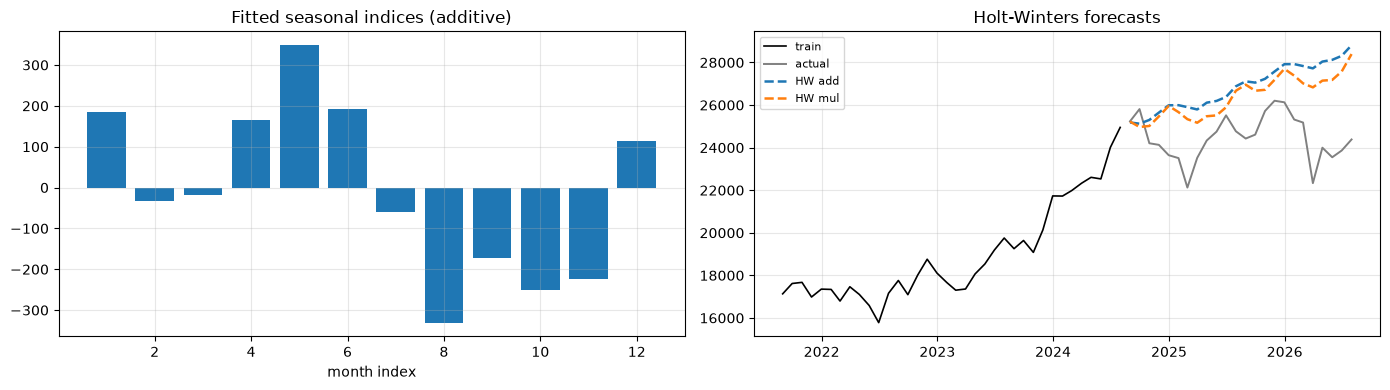

In [10]:
hw_add = ExponentialSmoothing(train, trend="add", seasonal="add",
                              seasonal_periods=M, initialization_method="estimated").fit()
hw_mul = ExponentialSmoothing(train, trend="add", seasonal="mul",
                              seasonal_periods=M, initialization_method="estimated").fit()

fc["HW add"] = hw_add.forecast(H)
fc["HW mul"] = hw_mul.forecast(H)

for nm, f in [("HW additive", hw_add), ("HW multiplicative", hw_mul)]:
    p = f.params
    print(f"{nm:18s} α={p['smoothing_level']:.4f}  β*={p['smoothing_trend']:.4f}  γ={p['smoothing_seasonal']:.4f}")

seas = np.asarray(hw_add.params["initial_seasons"], float)
print(f"\nHW additive seasonal indices: {seas.min():,.0f} to {seas.max():,.0f} points "
      f"({(seas.max()-seas.min())/train.mean()*100:.2f}% of mean level)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(1, M + 1), seas)
axes[0].set_xlabel("month index"); axes[0].set_title("Fitted seasonal indices (additive)")

axes[1].plot(train.index[-36:], train.values[-36:], lw=1.2, color="black", label="train")
axes[1].plot(test.index, test.values, lw=1.4, color="grey", label="actual")
for k in ("HW add", "HW mul"):
    axes[1].plot(test.index, fc[k], lw=1.8, ls="--", label=k)
axes[1].legend(fontsize=8); axes[1].set_title("Holt-Winters forecasts")
plt.tight_layout(); plt.show()

**Additive HW estimates γ = 0.0000** — the seasonal indices never update from their initial values. The optimiser found no seasonal signal worth tracking, which is exactly what $F_{\text{seasonal}} = 0.000$ predicted in §0. The fitted indices span roughly 680 points, under 5% of the mean level, and they are fitting noise: there is no repeatable month-of-year effect in an equity index.

→ This is the honest use of Holt-Winters on this data: it demonstrates **when not to use it**. On a seasonal series (the bakery data in [EDA.ipynb](EDA.ipynb), $F_s = 0.63$) γ would be well away from zero.

## 8. Comparing the methods

All ten forecasts on the same 24-month holdout, scored with MAE, RMSE and MASE (denominator = in-sample one-step naïve, so **MASE < 1 beats naïve**).

In [11]:
mase_den = np.abs(np.diff(train.values)).mean()

rows = []
for name, f in fc.items():
    f = np.asarray(f, float)
    e = test.values - f
    rows.append({"method": name,
                 "MAE":  round(np.abs(e).mean(), 1),
                 "RMSE": round(np.sqrt((e ** 2).mean()), 1),
                 "MASE": round(np.abs(e).mean() / mase_den, 2)})

single = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)
single

,method,MAE,RMSE,MASE
0,Naive,940.7,1155.1,1.94
1,SES,940.7,1155.1,1.94
2,SMA(3),997.8,1228.9,2.06
3,WMA(6),1152.7,1402.4,2.38
4,SMA(6),1541.7,1751.3,3.18
5,HW mul,1981.9,2307.4,4.09
6,Holt damped,2044.4,2382.6,4.22
7,HW add,2432.2,2781.2,5.02
8,Drift,2661.4,3048.3,5.49
9,Holt,2661.4,3048.3,5.49


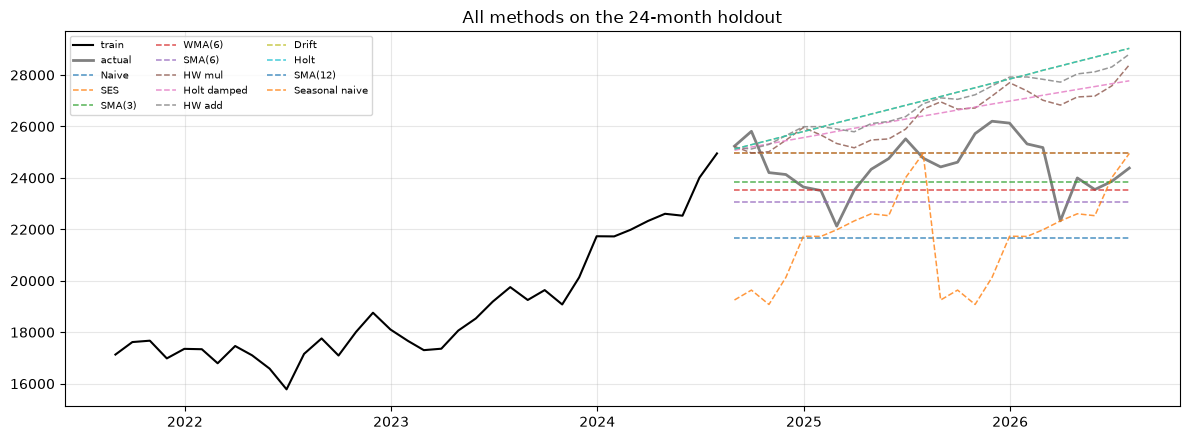

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(train.index[-36:], train.values[-36:], lw=1.5, color="black", label="train")
ax.plot(test.index, test.values, lw=2, color="grey", label="actual")
for name in single["method"]:
    ax.plot(test.index, np.asarray(fc[name], float), lw=1.1, ls="--", alpha=0.8, label=name)
ax.legend(fontsize=7, ncol=3); ax.set_title("All methods on the 24-month holdout")
plt.tight_layout(); plt.show()

**One-window result:** naïve wins (MAE 941), and every trend method is far worse — drift and Holt land at 2661. But the training period ended after a strong bull run and the test window was flat-to-down (train ends 24,951; test mean 24,470). Any method that extrapolates the past slope was guaranteed to overshoot.

That is a statement about **this window**, not about the methods. Re-score over a rolling origin before concluding anything.

In [13]:
def all_forecasts(tr, h):
    out = {}
    out["Naive"]          = naive(tr, h)
    out["Seasonal naive"] = seasonal_naive(tr, h)
    out["Drift"]          = drift(tr, h)
    out["SMA(3)"]         = sma(tr, h, 3)
    out["WMA(6)"]         = wma(tr, h, 6)
    out["SES"]            = SimpleExpSmoothing(tr, initialization_method="estimated").fit().forecast(h)
    out["Holt"]           = Holt(tr, initialization_method="estimated").fit().forecast(h)
    out["Holt damped"]    = Holt(tr, damped_trend=True, initialization_method="estimated").fit().forecast(h)
    out["HW add"]         = ExponentialSmoothing(tr, trend="add", seasonal="add",
                                                 seasonal_periods=M, initialization_method="estimated").fit().forecast(h)
    out["HW mul"]         = ExponentialSmoothing(tr, trend="add", seasonal="mul",
                                                 seasonal_periods=M, initialization_method="estimated").fit().forecast(h)
    return out

h_cv = 12
errors = {}
cutoffs = range(60, len(nifty) - h_cv + 1, 6)      # expanding origin, 6-month steps

for c in cutoffs:
    tr, te = nifty[:c], nifty[c:c + h_cv]
    for name, f in all_forecasts(tr, h_cv).items():
        errors.setdefault(name, []).append(np.abs(te.values - np.asarray(f, float)).mean())

cv = (pd.DataFrame([{"method": k, "mean MAE": round(np.mean(v), 1),
                     "median MAE": round(np.median(v), 1)} for k, v in errors.items()])
      .sort_values("mean MAE").reset_index(drop=True))
print(f"rolling origin: {len(list(cutoffs))} windows, h = {h_cv} months")
cv

rolling origin: 9 windows, h = 12 months


,method,mean MAE,median MAE
0,HW mul,1078.2,945.9
1,Drift,1084.0,1070.3
2,Holt,1084.1,1044.9
3,HW add,1102.4,1099.3
4,Holt damped,1106.0,1182.0
5,Naive,1352.7,1318.9
6,SES,1352.7,1318.9
7,SMA(3),1478.0,1392.8
8,WMA(6),1572.9,1408.4
9,Seasonal naive,2344.0,1975.2


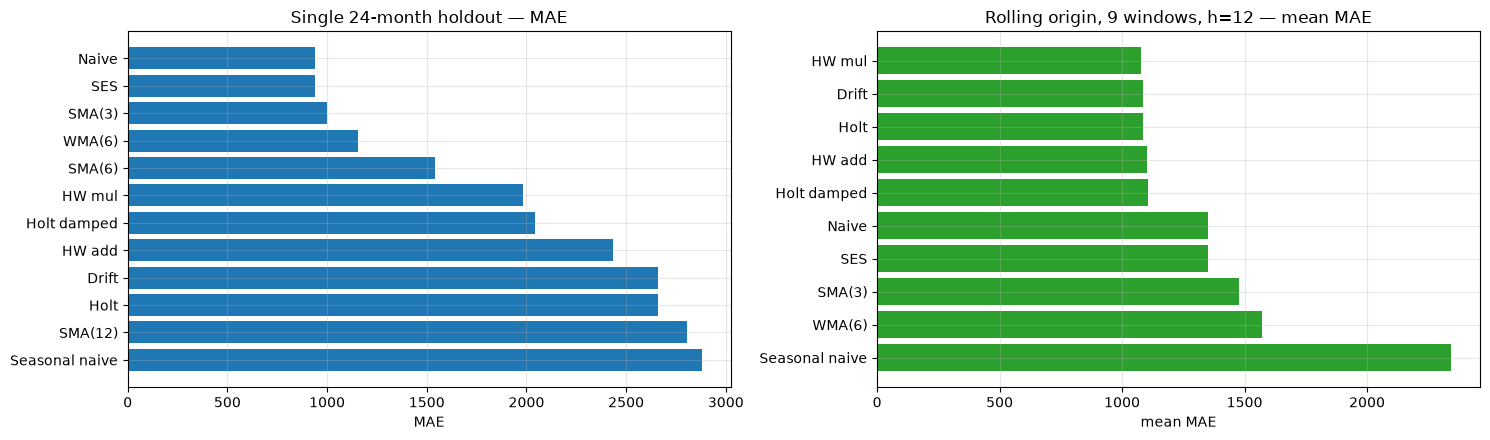

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))

axes[0].barh(single["method"][::-1], single["MAE"][::-1], color="tab:blue")
axes[0].set_title("Single 24-month holdout — MAE"); axes[0].set_xlabel("MAE")

axes[1].barh(cv["method"][::-1], cv["mean MAE"][::-1], color="tab:green")
axes[1].set_title(f"Rolling origin, {len(list(cutoffs))} windows, h=12 — mean MAE")
axes[1].set_xlabel("mean MAE")

plt.tight_layout(); plt.show()

**The ranking inverts.** Across 9 rolling windows the trend methods come out on top — HW multiplicative 1078, drift 1084, Holt 1084 — while naïve drops to 6th at 1353. The single-window result was an artefact of one flat test period.

### Naïve vs seasonal naïve vs drift

| | Forecast | Optimal when | Here |
|---|---|---|---|
| Naïve | $y_T$ | random walk | mean MAE 1353 |
| Seasonal naïve | $y_{T+h-m\lceil h/m\rceil}$ | strong stable seasonality | **worst, 2344** — no seasonality to exploit |
| Drift | $y_T + h\frac{y_T-y_1}{T-1}$ | random walk **with drift** | **1084** — matches the data-generating process |

Drift beats naïve by 20% on average, exactly as §0 predicted: the series has a real +10.6%/yr drift, and naïve throws that information away.

### Moving average vs exponential smoothing

Both give flat forecasts, so both lose to trend methods here (SMA(3) 1478, WMA(6) 1573 vs drift 1084). Between them, exponential smoothing is strictly the better tool: smooth decay instead of a hard cutoff, all history used, and $\alpha$ fitted by MLE rather than $k$ guessed. SMA(3) beats WMA(6) only because its shorter effective memory lags less.

### SES vs Holt vs Holt-Winters

- **SES 1353** — identical to naïve, since $\alpha \to 1$. No trend term, so it cannot track the drift.
- **Holt 1084 / damped 1106** — the trend term is what closes the gap. Damping did not help on average here because the drift is genuinely persistent; it would win in a market that mean-reverts.
- **HW mul 1078 / add 1102** — nominally best, but with $\gamma \approx 0$ the seasonal component is inert. HW is not winning *because* of seasonality; it is essentially Holt with extra parameters, and the tiny margin over Holt (1078 vs 1084, 0.6%) is noise.

### Choosing a method

| Trend | Seasonality | Variance | Method |
|---|---|---|---|
| none | none | stable | SES (or naïve) |
| none | none | noisy level | SES with small $\alpha$ |
| linear | none | stable | Holt |
| uncertain / may flatten | none | any | **Holt damped** |
| linear | yes, constant amplitude | stable | Holt-Winters additive |
| linear | yes, amplitude grows with level | grows with level | Holt-Winters multiplicative (or log + additive) |
| stochastic (unit root) | none | any | naïve / drift |
| any | yes, strong | any | seasonal naïve as the baseline to beat |

### Strengths and limitations

| Method | Strength | Limitation |
|---|---|---|
| Naïve | optimal for a random walk; zero parameters | ignores trend and seasonality |
| Seasonal naïve | captures seasonality free | useless without it; uses one noisy observation per season |
| Drift | optimal for a random walk with drift | slope depends on only two points; extrapolates forever |
| SMA | trivially simple | flat forecast, equal weights, hard cutoff, lags by $(k-1)/2$ |
| WMA | less lag than SMA | still a cutoff and a flat forecast; weights chosen by hand |
| SES | smooth decay, one MLE parameter, $O(1)$ update | flat forecast — fails on a trend |
| Holt | tracks a linear trend | extrapolates indefinitely; can overshoot badly |
| Holt damped | robust over long horizons | $\phi$ is another parameter; under-shoots a persistent trend |
| Holt-Winters | full level/trend/season | $m + 3$ parameters; overfits when seasonality is weak |

**The result that matters most on this data:** every MASE in the holdout table exceeds 1. On an index that is a random walk with drift, no classical method beats the in-sample one-step naïve benchmark — the honest conclusion, and the reason naïve is the baseline every forecast must clear.